<a href="https://colab.research.google.com/github/JoseAlberto88/Predictive-Analytics-/blob/main/DAMO510_Module_04_in_Class_Activity_Starter_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# For this activity we need to cover the following tasks:

1- Data loading, inspection, duplicate removal, missing-value treatment, and outlier handling.

2- Log transformation of skewed predictors.

3- Correlation-based feature selection and collinearity handling.

4- Baseline multiple linear regression.

5- Linear regression using selected log-transformed predictors.

6- Box-Cox transformation of the response.

7- Log transformation of the response.

8- Second-degree polynomial regression.

9- R^2 and RMSE comparison on the original MEDV scale.

10- Overall F-tests and predictor-level coefficient, t-statistic, and p-value reports.

11- Residual plots, residual histograms, and Q-Q plots.

12- A common train/test split for fair model comparison.

13 - Prediction of one sample case

In other words, steps should include:

1)	Data preparation
2)	Correlation analysis
3)	Feature selection
4)	Multicollinearity handling
5)	Baseline linear regression
6)	Log-transformed predictors
7)	Box-Cox response
8)	Log response
9)	Polynomial regression
10)	Model comparison
11)	Visualization
12)	Single-case prediction


## First few steps are done for you since they cover last two modules. this way you can focus on the topics of this module.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.special import inv_boxcox

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data_path = file_path = '/content/drive/MyDrive/Predictive Analytics Course/BostonHousing.csv'

df_a = pd.read_csv(data_path)
df_a.columns = df_a.columns.str.strip().str.lower()


print("Initial shape:", df_a.shape)
display(df_a.head())
display(df_a.info())


Initial shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


None

In [6]:
target = "medv"

duplicate_count = df_a.duplicated().sum()
missing_before = df_a.isna().sum()

print("Duplicate rows:", duplicate_count)
print("\nMissing values before cleaning:")
display(missing_before.to_frame("missing_count"))

df_b = df_a.drop_duplicates().copy()

numeric_columns = df_b.select_dtypes(include=np.number).columns
df_b[numeric_columns] = df_b[numeric_columns].fillna(df_b[numeric_columns].median())

print("Shape after duplicate removal and median imputation:", df_b.shape)
print("Total missing values after cleaning:", int(df_b.isna().sum().sum()))
display(df_b.head())


Duplicate rows: 0

Missing values before cleaning:


,missing_count
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


Shape after duplicate removal and median imputation: (506, 14)
Total missing values after cleaning: 0


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [7]:
predictor_columns = [col for col in numeric_columns if col != target]

outlier_indices = {}

for col in predictor_columns:
    skewness = df_b[col].skew()

    if abs(skewness) < 0.5:
        z_scores = np.abs(stats.zscore(df_b[col], nan_policy = "omit"))
        mask = z_scores > 3
        method = "|Z-score| > 3"
    else:
        q1 = df_b[col].quantile(0.25)
        q3 = df_b[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        mask = (df_b[col] < lower_bound) | (df_b[col] > upper_bound)
        method = "1.5 * IQR"

    outlier_indices[col] = df_b.index[mask]
    print(
        f"{col:<10} skewness = {skewness:>7.3f} | "  # left align and pad with 10 spaces
        f"{method:<15} | detected = {int(mask.sum())}"
    )
# what Python doies in the above line is Same as below:
# print(f"{col:<10} skewness = {skewness:>7.3f} | {method:<15} | detected = {int(mask.sum())}")

crim       skewness =   5.223 | 1.5 * IQR       | detected = 66
zn         skewness =   2.226 | 1.5 * IQR       | detected = 68
indus      skewness =   0.295 | |Z-score| > 3   | detected = 0
chas       skewness =   3.406 | 1.5 * IQR       | detected = 35
nox        skewness =   0.729 | 1.5 * IQR       | detected = 0
rm         skewness =   0.404 | |Z-score| > 3   | detected = 8
age        skewness =  -0.599 | 1.5 * IQR       | detected = 0
dis        skewness =   1.012 | 1.5 * IQR       | detected = 5
rad        skewness =   1.005 | 1.5 * IQR       | detected = 0
tax        skewness =   0.670 | 1.5 * IQR       | detected = 0
ptratio    skewness =  -0.802 | 1.5 * IQR       | detected = 15
b          skewness =  -2.890 | 1.5 * IQR       | detected = 77
lstat      skewness =   0.906 | 1.5 * IQR       | detected = 7


Approximately normal predictors: ['indus', 'rm']
Rows removed: 8
Shape after outlier handling: (498, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


#Transform Skewed Predictors
The objective of this step is to reduce the skewness of continuous predictor variables while preserving the original variables. Instead of replacing the existing predictors, you will create new transformed versions that can later be compared with the originals during model development.

###Complete the following tasks:

1. Create a list containing only the continuous predictor variables. Exclude predictors that represent categorical or discrete variables (such as CHAS and RAD) since logarithmic transformations are generally not appropriate for these variables. why? read below:

(for example for RAD (Accessibility to Radial Highways)

Values might be 1,2,3,4,5,...,24. At first glance this looks continuous. It isn't. RAD is actually an index. For example,
RAD = 2,
RAD = 4,
RAD = 24, do not mean 24 is twelve times more accessible than 2. They simply represent categories of highway accessibility. The numeric values are codes assigned by the dataset creators.)


2. From the continuous predictors, identify those whose absolute skewness is greater than or equal to 0.5. `These variables are considered sufficiently skewed to benefit from a transformation`.

3. Create a new DataFrame (e.g., df_d) as a copy of the cleaned dataset. Do not overwrite the previous DataFrame.

4. Loop through each skewed predictor and apply a logarithmic transformation.

5. Before transforming a variable, determine whether it contains negative values.

-	If the variable contains only zero or positive values, apply the logarithmic transformation directly.

-	If the variable contains negative values, first shift the entire variable upward so that its minimum value becomes positive, and then apply the logarithmic transformation. But, why not applying the absolute value instead of shifting the variabel? beacuse taking the absolute value changes the meaning of the data, whereas shifting the data preserves the ordering and distances between observations, and will completely change the information contained in the variable.

6. Store each transformed variable as a new column by adding an appropriate prefix (for example, log_) to its original name. Keep the original predictor unchanged.

7. After all transformations have been completed, display:

- The names of the transformed predictors,
- The dimensions of the new dataframe, and
- The first few rows of the updated dataset to verify that the new variables were created successfully.



Skewed predictors transformed: ['crim', 'zn', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'b', 'lstat']
Shape after adding transformed predictors: (498, 24)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,...,log_crim,log_zn,log_nox,log_rm,log_age,log_dis,log_tax,log_ptratio,log_b,log_lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,...,0.006300,2.944439,0.430483,2.024853,4.192680,1.627278,5.693732,2.791165,5.986201,1.788421
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,...,0.026944,0.000000,0.384582,2.004314,4.380776,1.786261,5.493061,2.933857,5.986201,2.316488
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,...,0.026924,0.000000,0.384582,2.102303,4.128746,1.786261,5.493061,2.933857,5.975919,1.615420
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,...,0.031857,0.000000,0.377066,2.079192,3.845883,1.954757,5.407172,2.980619,5.980479,1.371181
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,...,0.066770,0.000000,0.377066,2.097650,4.010963,1.954757,5.407172,2.980619,5.986201,1.845300


#Prepare the dataset for correlation analysis

The objective of this step is to create the dataset that will be used for feature selection. Whenever a transformed version of a predictor is available, it will replace the original predictor in the correlation analysis. This allows the remaining workflow to evaluate the transformed variables instead of their more skewed counterparts.

## Complete the following tasks:

1- Create a list that will contain all variables used for Stage 1 modelling.

2- Begin the list with the target variable.

3- Loop through all predictor variables.

4- If a logarithmically transformed version of a predictor exists in the dataset, add the transformed variable to the list. Otherwise, add the original predictor.

5- Ensure that only one version of each predictor (either the original or the transformed version) is included.

6- Create a new DataFrame containing only the selected variables. Do not overwrite the previous DataFrame.

7- Compute the correlation matrix for all numerical variables in the new DataFrame.

8- Visualize the correlation matrix using a heatmap.

9- Display the correlation coefficients on the heatmap. Use an appropriate diverging colour map to distinguish positive and negative correlations.

10- Set the colour scale to range from -1 to +1.

11- Include an informative figure title.

12- Examine the heatmap to identify:

- Predictors that have a weak relationship with the target variable,
- Predictors that are highly correlated with one another (multicollinearity), and
- Any other notable relationships that may influence the regression model.

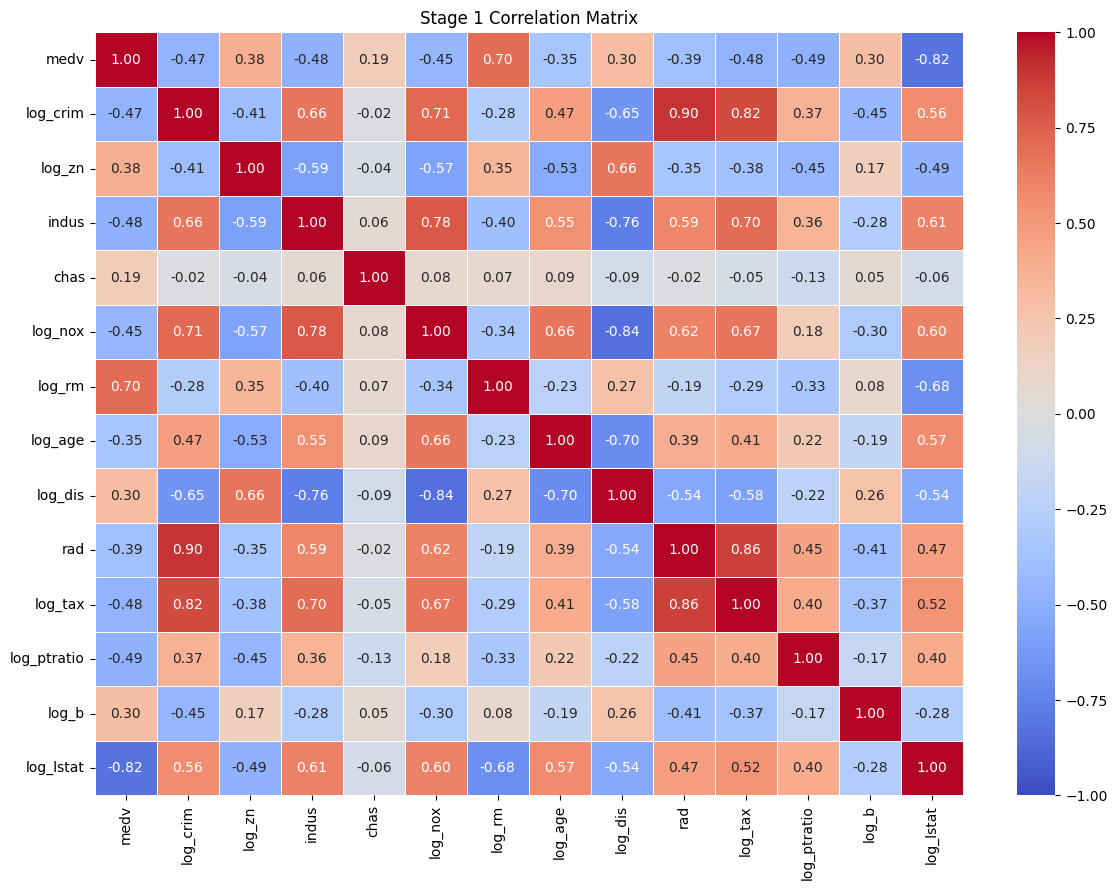

#Identify predictors with weak relationships to the target

The objective of this step is to identify predictors that have little or no linear relationship with the target variable. Variables that are only weakly correlated with the target generally contribute less to a linear regression model and may be considered for removal.

## Complete the following tasks:

1. Retrieve the correlation coefficients between each predictor and the target variable from the correlation matrix.

2. Exclude the target variable itself from the resulting list of correlations.

3. Sort the predictors in descending order according to the absolute value of their correlation coefficients so that the strongest relationships appear first, regardless of whether they are positive or negative.

4. Identify all predictors whose absolute correlation coefficient is `less than 0.30`. These variables are considered to have a weak linear relationship with the target.

5. Store the names of these weakly correlated predictors in a separate list for use in the next feature selection step.

6. Display:

-	A table showing the correlation coefficient between each predictor and the target variable, sorted by the strength of the relationship, and

-	The list of predictors identified for removal because their absolute correlation with the target is less than 0.30.



Correlations with the target:


,correlation_with_medv
log_lstat,-0.815589
log_rm,0.698049
log_ptratio,-0.489592
indus,-0.481806
log_tax,-0.476285
log_crim,-0.470000
log_nox,-0.450669
rad,-0.386076
log_zn,0.383803
log_age,-0.349268


Features removed because |r with target| < 0.30:
['log_b', 'chas']


# Identify highly correlated predictors (multicollinearity)

The objective of this step is to identify predictors that provide similar information. When two predictors are highly correlated with one another, they may introduce multicollinearity, making the regression coefficients unstable and more difficult to interpret.

## Complete the following tasks:

1. Create a new DataFrame by removing the predictors that were identified in the previous step as having a weak relationship with the target variable.

2. Create a list containing only the remaining predictor variables (exclude the target variable).

3. Compute the correlation matrix for the remaining predictors only.

4. Since the correlation matrix is symmetric, examine only one half of the matrix to avoid reporting the same predictor pair twice.

5. Identify all pairs of predictors whose absolute correlation coefficient is greater than 0.70.

6. Create a table that includes:

- The name of the first predictor,

- The name of the second predictor, and

- Their absolute correlation coefficient.

7. Sort the table so that the predictor pairs with the strongest correlations appear first.

8. Display the resulting table for further evaluation.

`Important`: Do not remove any predictors in this step. The objective here is only to identify highly correlated predictor pairs. The decision of which predictor to keep should be based on statistical evidence and domain knowledge in the following step.

,feature_1,feature_2,absolute_correlation
6,log_crim,rad,0.904216
49,rad,log_tax,0.860657
29,log_nox,log_dis,0.836391
7,log_crim,log_tax,0.822835
19,indus,log_nox,0.775499
22,indus,log_dis,0.759957
2,log_crim,log_nox,0.714914
24,indus,log_tax,0.701164


# Handle multicollinearity

The objective of this step is to remove redundant predictors while preserving the variables that are expected to contribute the most to the regression model.

When two predictors contain similar information, only one should be retained.

## Complete the following tasks:

1. Create an empty collection (a set) to store the names of predictors that will be removed because of multicollinearity.

2. Examine each highly correlated predictor pair identified in the previous step.

3. Before evaluating a pair, verify that neither predictor has already been marked for removal. If one of them has already been selected for removal, skip that pair and continue with the next one.

4. For each remaining pair, calculate the absolute correlation between each predictor and the target variable.

5. Compare the two correlation values:

-	Retain the predictor that has the stronger relationship with the target variable.

-	Mark the predictor with the weaker relationship for removal.

6. After all highly correlated pairs have been evaluated, organize the list of predictors selected for removal.

7. Create a new DataFrame by removing these redundant predictors. Do not overwrite the previous DataFrame.

8. Create a list containing the final set of predictor variables that will be used in the Stage 1 regression model.

9. Display:

-	the list of predictors removed because of multicollinearity,
-	the final list of selected predictors, and
-	the dimensions and first few rows of the resulting DataFrame.

### Important:

There are several valid ways to handle multicollinearity. In this activity, the selection is based on which predictor has the stronger absolute correlation with the target variable. In real-world applications, additional factors such as domain knowledge, interpretability, data quality, measurement reliability, and business relevance should also be considered before removing a predictor.


Features removed for collinearity:
['log_crim', 'log_dis', 'log_nox', 'log_tax', 'rad']

Selected Stage 1 features:
['log_zn', 'indus', 'log_rm', 'log_age', 'log_ptratio', 'log_lstat']

Final Stage 1 shape: (498, 7)


,medv,log_zn,indus,log_rm,log_age,log_ptratio,log_lstat
0,24.0,2.944439,2.31,2.024853,4.192680,2.791165,1.788421
1,21.6,0.000000,7.07,2.004314,4.380776,2.933857,2.316488
2,34.7,0.000000,7.07,2.102303,4.128746,2.933857,1.615420
3,33.4,0.000000,2.18,2.079192,3.845883,2.980619,1.371181
4,36.2,0.000000,2.18,2.097650,4.010963,2.980619,1.845300


# Verify that multicollinearity has been reduced

The objective of this step is to verify that the feature selection process has successfully reduced multicollinearity among the remaining predictors before building the regression model.

## Complete the following tasks:

1. Compute a new correlation matrix using only the predictors that were retained after the multicollinearity analysis.

2. Since the correlation matrix is symmetric, examine only one half of the matrix to avoid duplicate predictor pairs.

3. Identify any remaining predictor pairs whose absolute correlation coefficient is greater than 0.70.

4. Create a table containing:

- The name of the first predictor,
- The name of the second predictor, and
- Their absolute correlation coefficient.

5. Display the resulting table to verify whether any highly correlated predictor pairs still remain.

### Verification:

Ideally, the table should be empty, indicating that no predictor pairs exceed the selected multicollinearity threshold. If one or more pairs remain, further investigation may be required to determine whether additional feature selection or another multicollinearity reduction technique is appropriate.



Remaining predictor pairs with |r| > 0.70:


,feature_1,feature_2,absolute_correlation


# Prepare reusable functions and a common train-test split

The objective of this step is to prepare the common structure that will be used to build, evaluate, diagnose, and compare all regression models in this activity. Using the same observations for training and testing ensures that the model comparisons are fair.

## Complete the following tasks:

1. Create a function that converts a transformed predictor name back to its original variable name.

- For predictors whose names begin with log_, remove this prefix.
- For predictors that were not transformed, keep the original name unchanged.

2. Use this function to create a list of the original predictors represented by the final Stage 1 feature set.

3. Remove any duplicate predictor names from this list while preserving their original order.

4. Split the row indices of the final Stage 1 dataset into:

- a training set containing 80% of the observations, and
- a testing set containing 20% of the observations.

5. Use a fixed random seed so that the same training and testing observations are selected every time the notebook is run.

6. Use the selected indices to create the original-scale training and testing values for the target variable.

7. Create an empty dictionary that will store the performance results of all models developed later in the notebook.

8. Define a reusable function that records the following information for each model:

- model name,
- R^2,
- RMSE, and
- number of predictors or generated features.

9. Define a reusable diagnostic function that calculates residuals and produces:

- a residuals-versus-predicted-values scatter plot,
- a histogram of the residuals, and
- a Q-Q plot of the residuals.

10. In the residual plot, include a horizontal reference line at zero to help identify systematic patterns and changes in residual spread.

11.	Define a reusable statistical-significance function that:

- adds an intercept to the predictor matrix,
- fits an ordinary least squares regression model,
- reports the overall F-statistic and its p-value, and
- creates a table containing the coefficient, t-statistic, and p-value for every model term.

12.	Sort the coefficient table by p-value so that the most statistically significant terms appear first.

13.	Return the fitted statistical model from the significance function so that it can be examined later if required.

### Important:
All models in the notebook should use the same training and testing indices. Otherwise, differences in performance may be caused by different data splits rather than by the modelling approach itself.

### Note:
The predictive models developed later may use Scikit-learn, while the statistical-significance report uses Statsmodels. Scikit-learn is convenient for prediction and model evaluation, whereas Statsmodels provides detailed inferential statistics such as coefficients, t-tests, p-values, and the overall F-test.

# Build and evaluate the baseline linear regression model

The objective of this step is to establish a baseline model using the original versions of the selected predictors. This model will later be compared with models that use transformed predictors, transformed target values, and
polynomial features.

## Complete the following tasks:

1. Create the baseline predictor dataset using the selected original predictor variables from the cleaned dataset.

2. Use the previously created training and testing indices to divide the baseline predictors into:

- a training predictor dataset, and
- a testing predictor dataset.

3. Create a multiple linear regression model.

4. Fit the model using:

- the baseline training predictors, and
- the original-scale training values of the target variable.

5. Use the fitted model to predict the target values for the testing dataset.

6. Store the model's performance results using the previously defined results function. Record:

- testing R^2,
- testing RMSE, and
- the number of predictors used in the model.

7. Display the stored performance results for the baseline model.

8. Use the statistical-significance function to evaluate:

- the overall F-statistic,
- the overall F-test p-value,
- the regression coefficients,
- the t-statistics, and
- the p-values of the individual predictors.

9. Store the fitted Statsmodels regression object so that it can be examined later if needed.

10.	Use the diagnostic plotting function to create:

- a residuals-versus-predicted-values plot,
- a histogram of the residuals, and
- a Q-Q plot.

11.	Examine the model results and diagnostic plots to determine:

- how well the original predictors explain variation in MEDV,
- whether the model produces reasonably accurate predictions,
- whether the overall model is statistically significant,
- which individual predictors are statistically significant, and
- whether the residuals show evidence of nonlinearity, heteroscedasticity, outliers, or non-normality.

### Baseline model:
This model serves as the reference point for all later comparisons. A more complex model should be preferred only if it produces a meaningful improvement in predictive performance or model diagnostics.



{'R2': 0.7948274894955145, 'RMSE': np.float64(3.6635811089850763), 'Number_of_Features': 6}
Linear: Original Predictors overall F-statistic: 132.1173
Linear: Original Predictors overall F-test p-value: 7.82286e-91


,coefficient,t_statistic,p_value
lstat,-0.596120,-9.800015,2.020044e-20
rm,5.126383,9.328372,8.124041e-19
ptratio,-0.884326,-6.353436,5.861690e-10
const,13.760289,2.925381,3.640924e-03
zn,-0.017307,-1.147988,2.516752e-01
age,0.006212,0.418752,6.756274e-01
indus,0.010189,0.180683,8.567098e-01


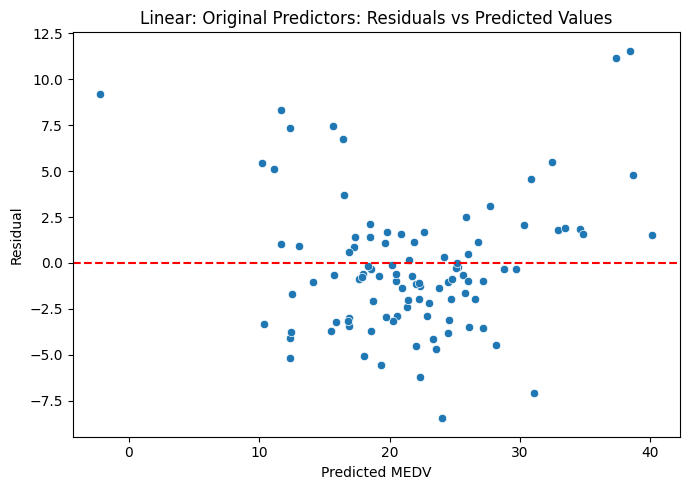

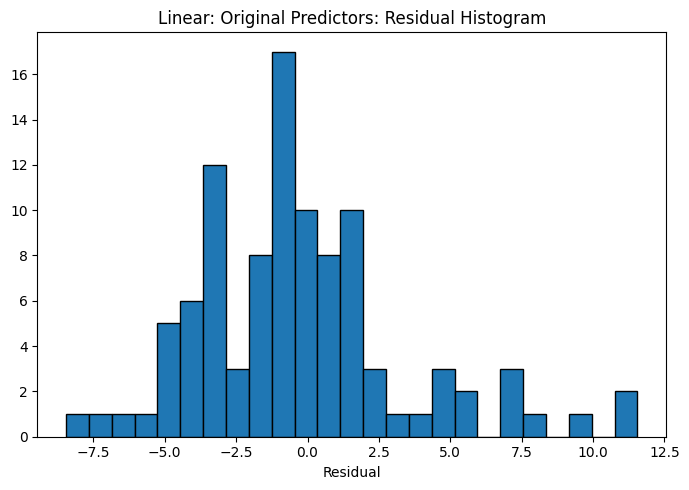

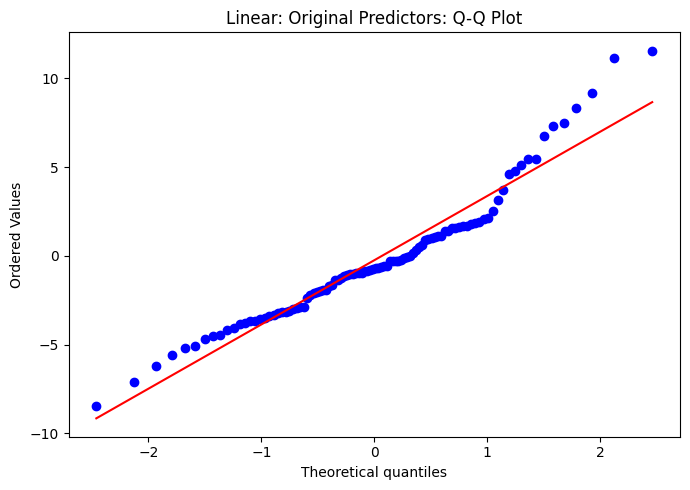

# Build and evaluate the linear model with log-transformed predictors
The objective of this step is to determine whether replacing skewed predictors with their logarithmically transformed versions improves the linear regression model.

## Complete the following tasks:

1. Create the predictor dataset using the final set of selected variables from the transformed dataset.

- Use the logarithmically transformed version of a predictor whenever it was selected during Stage 1.

- Use the original version for predictors that were not transformed.

2. Use the same training and testing indices created earlier to divide the predictor dataset into:

- a training predictor dataset, and
- a testing predictor dataset.

3. Create a multiple linear regression model.

4. Fit the model using:

- the selected transformed training predictors, and
- the original-scale training values of the target variable.

5. Use the fitted model to predict the original-scale target values for the testing dataset.

6. Store the model's results using the previously defined results function. Record:

- testing R^2,
- testing RMSE, and
- the number of predictors used.

7.Display the stored performance results.

8.Use the statistical-significance function to examine:

- the overall F-statistic,
- the overall F-test p-value,
- the regression coefficients,
- the t-statistics, and
- the p-values of the individual predictors.

9. Store the fitted Statsmodels regression object for possible later inspection.

10.	Use the diagnostic plotting function to produce:

- a residuals-versus-predicted-values plot,
- a residual histogram, and
- a Q-Q plot.

11.	Compare this model with the baseline model and determine whether the transformed predictors:

- improve testing R^2,
- reduce testing RMSE,
- produce more random residual patterns,
- improve the normality of residuals, or
- change the statistical significance of individual predictors.

### Important:
In this model, only the predictors are transformed. The target variable remains on its original MEDV scale, so the predictions and RMSE can be compared directly with those of the baseline model.



{'R2': 0.8199735605544278, 'RMSE': np.float64(3.4317399517565197), 'Number_of_Features': 6}
Linear: Selected Log-Transformed Predictors overall F-statistic: 170.1107
Linear: Selected Log-Transformed Predictors overall F-test p-value: 1.01385e-105


,coefficient,t_statistic,p_value
log_lstat,-11.537457,-14.854501,6.813876e-40
log_ptratio,-14.793921,-6.225071,1.241870e-09
log_rm,22.438662,5.792345,1.428415e-08
const,44.714750,3.989734,7.897732e-05
log_age,1.465870,2.542542,1.138970e-02
log_zn,-0.414509,-1.993010,4.695492e-02
indus,0.003940,0.078607,9.373854e-01


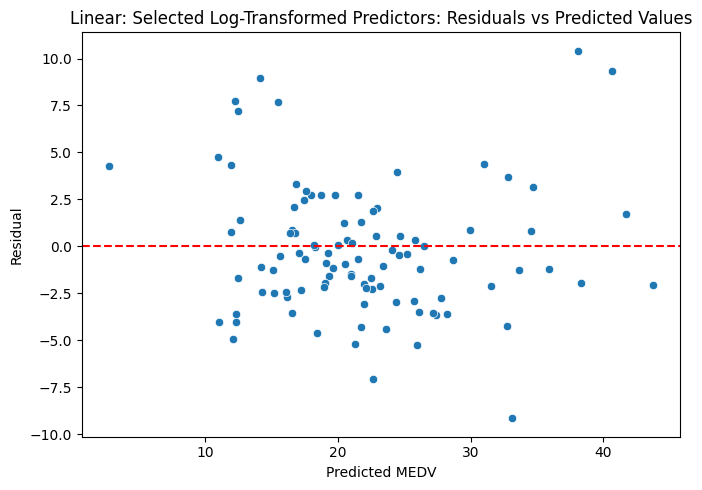

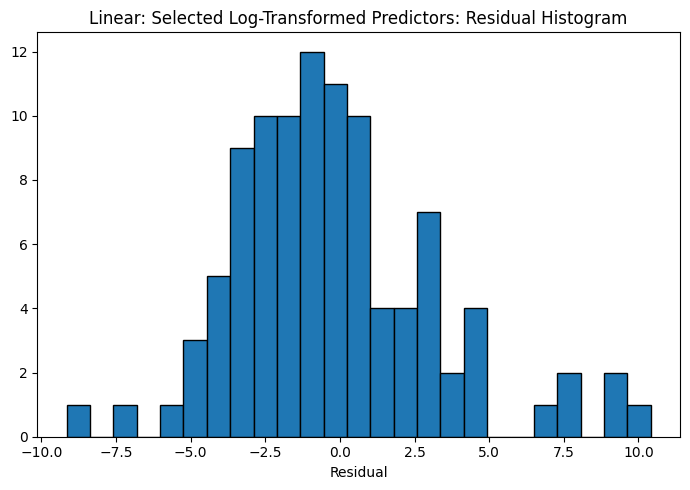

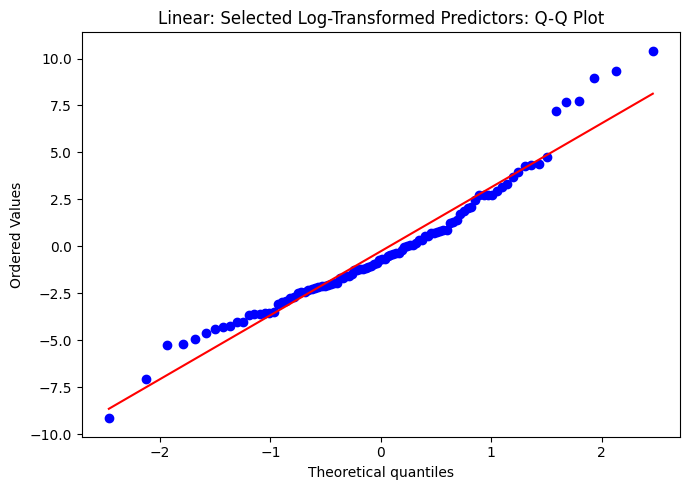

# Box-Cox transformation

The Box-Cox transformation is a mathematical technique used to transform the response (target) variable so that it more closely satisfies the assumptions of linear regression.

Unlike a simple logarithmic transformation, the Box-Cox method automatically searches for the transformation that best improves the distribution of the response variable. It estimates a parameter, called λ (lambda), that determines the most appropriate power transformation.

Depending on the value of λ, the transformation may resemble one of several familiar transformations:

•	λ ~ 1 : little or no transformation is required.

•	λ ~ 0 : the transformation becomes approximately a logarithmic transformation.

•	λ < 1 : compresses larger values more than smaller ones, reducing right skewness.

•	λ > 1 : may stretch larger values if appropriate for the data.

The primary objectives of the Box-Cox transformation are to:

1. Reduce skewness of the response variable,
2.	Improve the linear relationship between predictors and the response,
3.	Stabilize the variance of the residuals (homoscedasticity),
4.	Improve residual normality, and
5.	Potentially improve the predictive performance of the regression model.

One important limitation of the Box-Cox transformation is that it can only be applied when all response values are strictly positive. If the response variable contains zero or negative values, another transformation, such as the `Yeo-Johnson transformation`, should be considered instead.
After fitting the regression model, the predictions are transformed back to the original response scale so that performance measures such as R^2 and RMSE can be interpreted and fairly compared with the previous models.


# Build and evaluate the box-cox response model

The objective of this step is to determine whether transforming the response variable using the Box-Cox transformation improves the regression model compared with using the original response variable.

## Complete the following tasks:

1. Verify that every value of the response variable is strictly greater than zero before applying the Box-Cox transformation.

2. Apply the Box-Cox transformation to the training values of the response variable.

3. Record the estimated value of the transformation parameter λ (lambda).

4. Using the same predictor variables selected in the previous model, create and fit a multiple linear regression model with:

- the selected predictor variables, and
- the Box-Cox-transformed response variable.

5. Use the fitted model to predict the transformed response values for the testing dataset.

6. Convert the predicted response values back to the original MEDV scale using the inverse Box-Cox transformation.

7. Store the model performance results using the original response values. Record:

- testing R^2,
- testing RMSE, and
- the number of predictors used.

8. Display:

- the estimated value of λ (lambda), and
- the stored performance results.

9. Use the statistical-significance function to evaluate:

-	the overall F-statistic,
-	the overall F-test p-value,
-	the regression coefficients,
-	the t-statistics, and
-	the p-values of the individual predictors.

10.	Use the diagnostic plotting function to produce:

-	a residuals-versus-predicted-values plot,
-	a residual histogram, and
-	a Q-Q plot.

11.	Compare this model with the previous linear regression models and determine whether the Box-Cox transformation:

-	improves testing R^2,
-	reduces testing RMSE,
-	improves the normality of the residuals,
-	reduces heteroscedasticity, and
-	produces a better overall regression model.

### Important:

Although the regression model is fitted using the transformed response variable, the final predictions must be converted back to the original MEDV scale before calculating performance measures. This ensures that all regression models developed in this activity are evaluated and compared on the same scale.S

Estimated Box-Cox lambda: 0.2454
{'R2': 0.8392496941008243, 'RMSE': np.float64(3.242814667436377), 'Number_of_Features': 6}
Linear: Box-Cox Response overall F-statistic: 177.8165
Linear: Box-Cox Response overall F-test p-value: 1.90607e-108


,coefficient,t_statistic,p_value
log_lstat,-1.097456,-15.380623,4.406481e-42
const,8.244720,8.007703,1.351935e-14
log_ptratio,-1.403203,-6.427179,3.787919e-10
log_rm,1.469767,4.129952,4.439222e-05
log_zn,-0.047809,-2.502214,1.274946e-02
log_age,0.096465,1.821294,6.932625e-02
indus,-0.008229,-1.786940,7.472177e-02


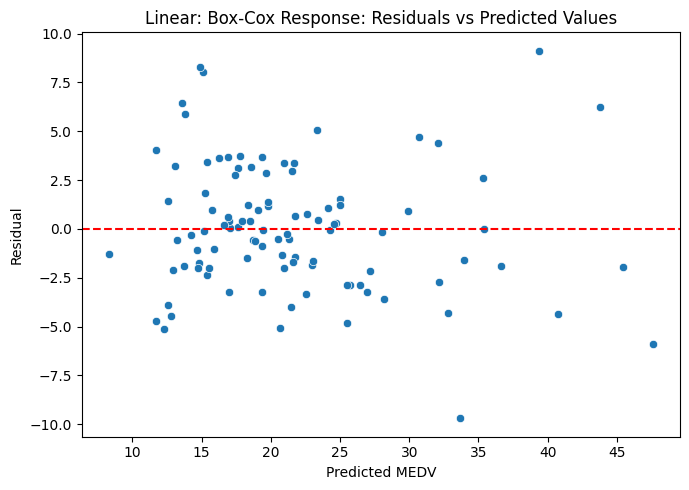

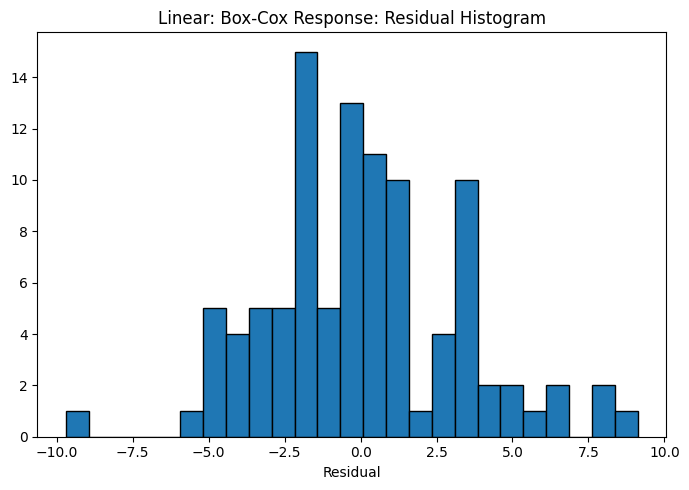

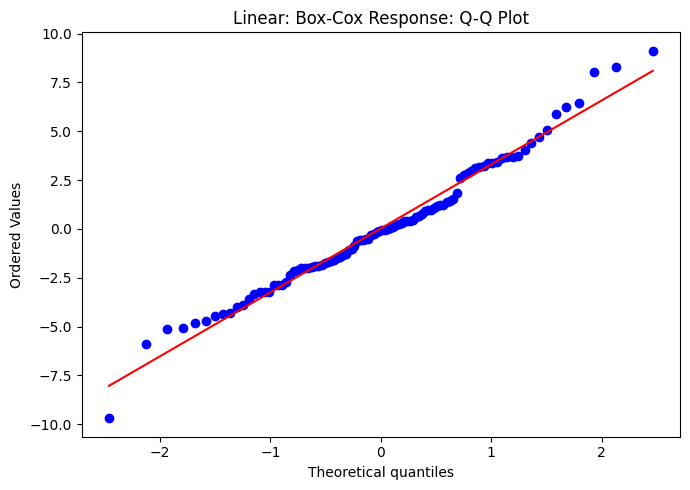

# Log transformation of the response variable

A log-transformed response model applies a logarithmic transformation to the target variable before fitting the regression model.
This approach is useful when the response variable is `right-skewed`, `contains unusually large values`, or `shows increasing residual variance as predicted values increase`.

The logarithmic transformation compresses larger response values more strongly than smaller values, which may improve linearity, residual normality, and homoscedasticity.

In this activity, the transformation uses:

$log⁡(1+y)$

Adding 1 allows the transformation to be applied when the response contains zero values. After prediction, the transformed results must be converted back to the original scale using the inverse transformation:



$e^{\widehat{y}}-1
$

This step is essential because the model is trained on the logarithmic scale, but the predictions and performance measures should be interpreted on the original MEDV scale.

# Build and evaluate the log-transformed response model

The objective of this step is to determine whether applying a logarithmic transformation to the response variable improves the regression model.

## Complete the following tasks:

1. Apply a logarithmic transformation to the training values of the target variable.

2. Create a new multiple linear regression model.

3. Fit the model using:

- the selected predictor variables, and
- the log-transformed training response values.

4. Use the fitted model to predict the response values for the testing predictors.

5. Recognize that the initial predictions are on the logarithmic scale.

6. Apply the inverse logarithmic transformation to convert the predicted values back to the original MEDV scale.

7. Store the model’s performance results using:

- the original testing response values, and
- the predictions converted back to the original scale.

8. Record:

- testing R^2,
- testing RMSE, and
- the number of predictors used.

9. Display the stored performance results.

10.	Use the statistical-significance function to evaluate the model on the transformed response scale, including:

- the overall F-statistic,
- the overall F-test p-value,
- the regression coefficients,
- the t-statistics, and
- the p-values of the individual predictors.

11.	Use the diagnostic plotting function to produce:

- a residuals-versus-predicted-values plot,
- a residual histogram, and
- a Q-Q plot.

12.	Compare this model with the baseline, log-predictor, and Box-Cox response models. Determine whether the log transformation:

- improves testing R^2,
- reduces testing RMSE,
- improves residual normality,
- reduces heteroscedasticity, or
- changes the significance of the predictors.

### Important:
The model is fitted using a transformed response, but R^2 and RMSE should be calculated after converting the predictions back to the original MEDV scale. This ensures a fair comparison with the other models.

{'R2': 0.8324162149266681, 'RMSE': np.float64(3.311023188333638), 'Number_of_Features': 6}
Linear: Log Response overall F-statistic: 168.4950
Linear: Log Response overall F-test p-value: 3.87915e-105


,coefficient,t_statistic,p_value
log_lstat,-0.496283,-15.047870,1.074012e-40
const,4.945943,10.392985,1.672912e-22
log_ptratio,-0.631747,-6.260407,1.011193e-09
log_rm,0.579721,3.524314,4.748317e-04
log_zn,-0.022666,-2.566498,1.064458e-02
indus,-0.004678,-2.197737,2.855355e-02
log_age,0.039334,1.606716,1.089238e-01


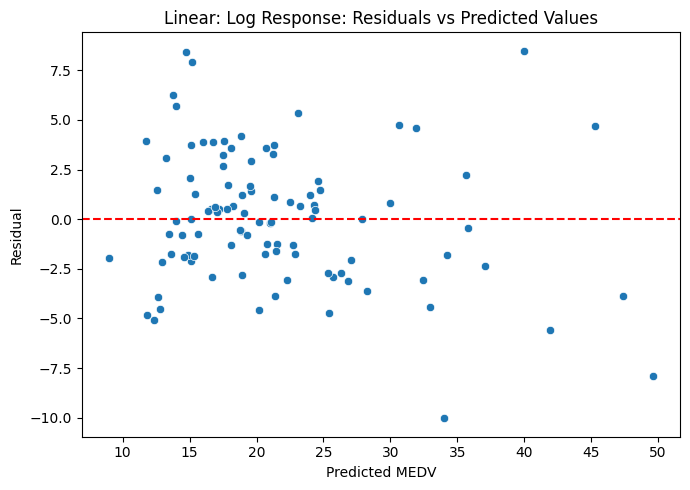

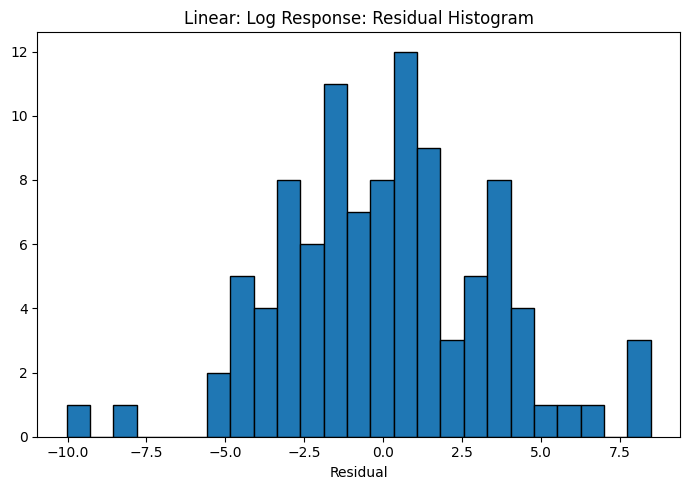

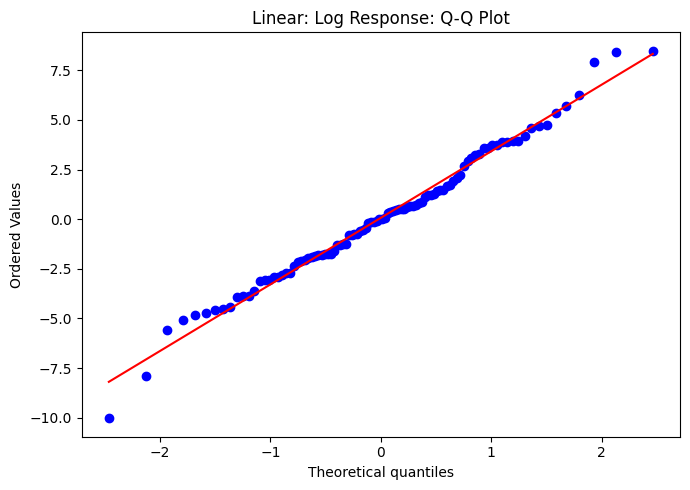

# Polynomial Regression

Multiple Linear Regression assumes that the relationship between each predictor and the response variable is linear. However, in many real-world problems, the relationship between variables is more complex.

For example, house prices may increase rapidly with the number of rooms up to a certain point and then level off, or the effect of one predictor may depend on the value of another predictor.

`Polynomial Regression` extends linear regression by creating additional predictor variables that capture these nonlinear relationships. Although the resulting model is still estimated using linear regression, it is no longer limited to fitting straight-line relationships.

In this activity, a second-degree polynomial model is used. This creates additional predictors such as:

-	the original predictors,
-	squared terms (e.g., $X_{1}^{2}$), and
-	interaction terms (e.g., $X_{1}\times X_{2}$).

These additional features allow the model to capture curved relationships and interactions between predictors that cannot be represented by an ordinary linear model.

One important consequence of polynomial regression is that the number of predictors increases substantially. While this often improves predictive performance, it also increases model complexity and may increase the risk of overfitting, where the model begins to fit random noise instead of the underlying relationship.


# Build and evaluate a second-degree polynomial regression model

The objective of this step is to determine whether introducing nonlinear and interaction terms improves the predictive performance of the regression model.

## Complete the following tasks:

1. Create a polynomial feature transformer that generates second-degree polynomial features while excluding an additional bias (intercept) term.

2. Use the transformer to generate the polynomial features for the training predictor dataset.

3. Apply the same fitted transformer to the testing predictor dataset to ensure that both datasets contain identical polynomial features.

4. Retrieve the names of all generated polynomial features.

5. Convert the transformed training and testing predictor arrays into DataFrames using:

- the generated feature names as column names, and
- the original row indices.

6. Create a multiple linear regression model.

7. Fit the model using:

- the polynomial training predictors, and
- the original training values of the target variable.

8. Use the fitted model to predict the target values for the testing dataset.

9. Store the model performance results, including:

- testing R^2,
- testing RMSE, and
- the total number of polynomial features generated.

10.	Display:

- the stored performance results, and
- the total number of predictors created by the polynomial transformation.

11.	Use the statistical-significance function to evaluate:

- the overall F-statistic,
- the overall F-test p-value,
- the regression coefficients,
- the t-statistics, and
- the p-values of the polynomial model terms.

12.	Use the diagnostic plotting function to produce:

- a residuals-versus-predicted-values plot,
- a residual histogram, and
- a Q-Q plot.

13.	Compare the polynomial regression model with the previous models developed in this activity. Determine whether adding nonlinear and interaction terms:

- improves testing R^2,
- reduces testing RMSE,
- improves the residual diagnostics,
- improves the statistical significance of the model, and
- justifies the increase in model complexity.

### Important:
A polynomial regression model often produces better predictive accuracy because it can model nonlinear relationships. However, improved performance should always be weighed against the increased model complexity and the possibility of overfitting. In practice, the preferred model is often the simplest one that provides satisfactory predictive performance and remains easy to interpret.

{'R2': 0.8756244366400825, 'RMSE': np.float64(2.8524218537228414), 'Number_of_Features': 27}
Polynomial feature count: 27
Polynomial Regression: Degree 2 overall F-statistic: 71.5734
Polynomial Regression: Degree 2 overall F-test p-value: 2.92221e-129


,coefficient,t_statistic,p_value
indus log_lstat,-1.023596,-6.600931,1.419433e-10
log_ptratio log_lstat,-31.071539,-5.060420,6.604165e-07
log_rm log_ptratio,-124.853737,-3.868943,1.291528e-04
log_zn log_lstat,-2.750419,-3.777965,1.842010e-04
log_lstat,104.655206,3.775459,1.859934e-04
log_lstat^2,3.430919,3.398642,7.509058e-04
log_age log_lstat,-5.313702,-3.292256,1.089558e-03
indus^2,0.026138,3.253617,1.244319e-03
log_rm^2,90.834310,3.184444,1.573306e-03
log_rm log_age,-26.496507,-2.914187,3.782942e-03


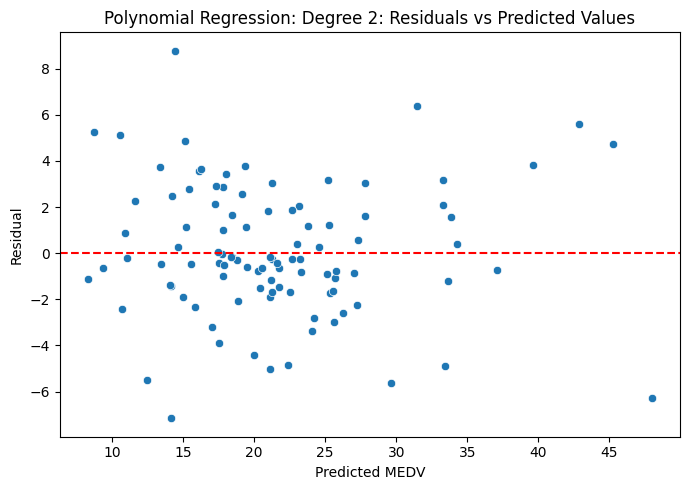

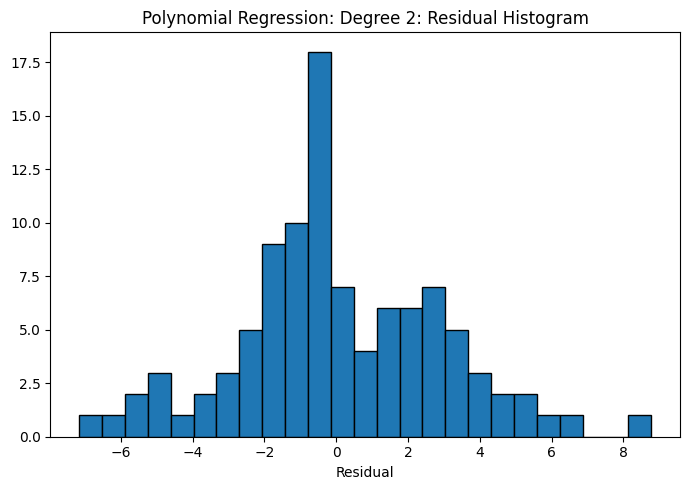

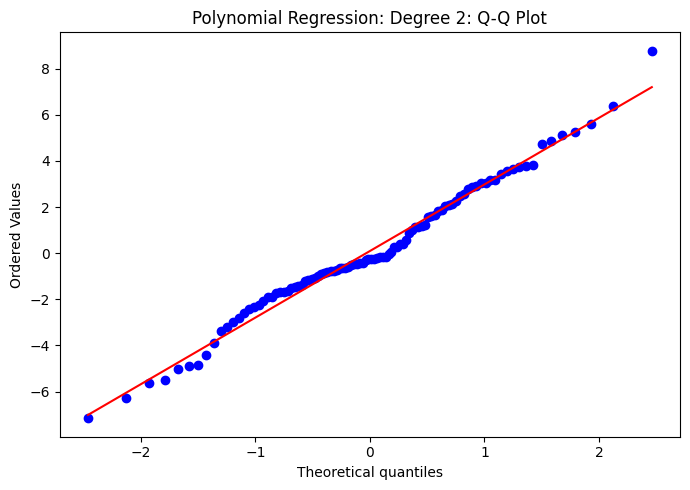

In [ ]:

)


# Compare the regression models

The objective of this step is to compare the performance of all regression models developed in this activity and identify the model that provides the best predictive performance.

## Complete the following tasks:

1. Create a summary table using the performance results collected from each regression model.

2. Organize the table so that each row represents one regression model and each column contains a performance measure.

3. Sort the table in ascending order of RMSE so that the model with the smallest prediction error appears first.

4. Improve the readability of the table by:

- Rounding the R^2 values to four decimal places,
- Rounding the RMSE values to four decimal places, and
- Displaying the number of predictors/features as whole numbers.

5. Display the completed comparison table.

6. Identify:

- The model with the lowest RMSE, and
- The model with the highest R^2.

7. Display the names of these models.

8. Compare the models by considering:

- predictive accuracy (RMSE),
- explanatory power (R^2),
- the number of predictors/features,
- statistical significance, and
- residual diagnostics.

9.Determine whether the model with the best predictive performance also represents the most appropriate choice when model complexity and interpretability are taken into account.

### Important:

The model with the highest R^2 is not necessarily the best model. Likewise, the model with the lowest RMSE may be substantially more complex than the alternatives. When selecting a final model, consider not only predictive performance, but also simplicity, interpretability, computational cost, and the risk of overfitting. In practice, analysts often prefer the simplest model that achieves satisfactory predictive performance.



,R2,RMSE,Number_of_Features
Polynomial Regression: Degree 2,0.8756,2.8524,27
Linear: Box-Cox Response,0.8392,3.2428,6
Linear: Log Response,0.8324,3.3110,6
Linear: Selected Log-Transformed Predictors,0.8200,3.4317,6
Linear: Original Predictors,0.7948,3.6636,6


Lowest-RMSE model: Polynomial Regression: Degree 2
Highest-R2 model: Polynomial Regression: Degree 2


# Visualize and compare model performance

The objective of this step is to create a visual comparison of the regression models so that differences in predictive performance can be identified more easily than from the summary table alone.

## Complete the following tasks:

1. Create a bar chart using the model comparison table developed in the previous step.

2. Include both of the primary performance measures:

- R^2, which measures the proportion of variation explained by the model, and
- RMSE, which measures the average prediction error.

3. Display both performance measures on the same chart using separate vertical axes so that each metric can be viewed using an appropriate scale.

4. Set an appropriate figure size so that all model names and bars can be displayed clearly.

5. Add a descriptive chart title that summarizes the purpose of the visualization.

6. Label the horizontal axis to indicate that each bar represents a different regression model.

7. Rotate the model names on the horizontal axis, if necessary, to improve readability and prevent overlapping labels.

8. Adjust the chart layout so that all labels, titles, and axes are fully visible.

9. Display the completed visualization.

10.	Use the chart to compare the regression models by identifying:

- the models with the highest R^2 values,
- the models with the lowest RMSE values,
- any models that achieve similar performance despite differing complexity, and
- whether increasing model complexity consistently improves predictive performance.

### Important:
Visualizations provide an effective way to compare competing models, but they should always be interpreted alongside the numerical performance measures and diagnostic plots. A model that appears to perform slightly better on a chart may not be preferable if the improvement is small relative to the increase in model complexity or the risk of overfitting.


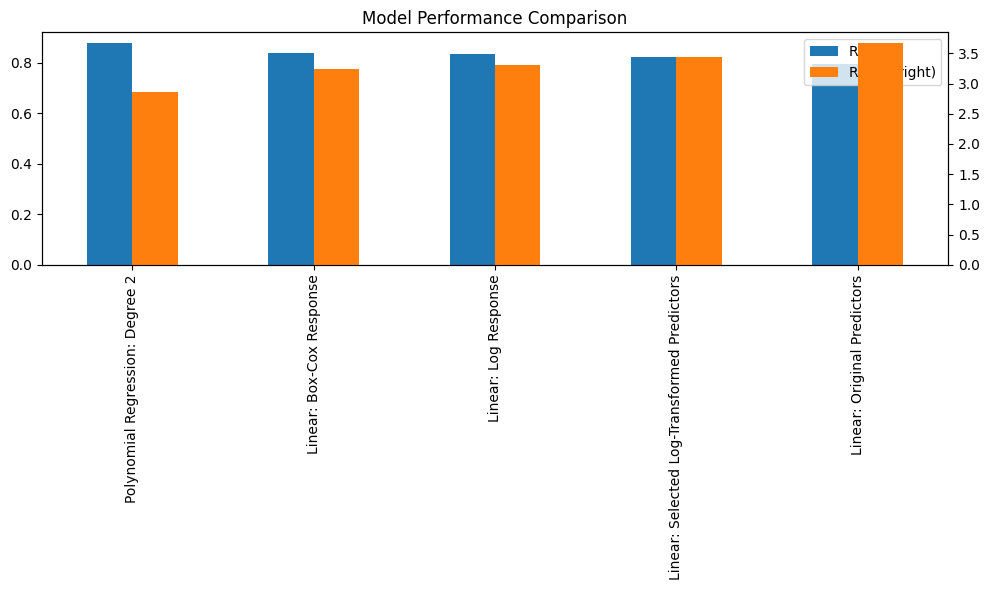

# Compare model predictions for a single test case

The objective of this final step is to examine how the regression models predict the response value for the same individual observation.

## Complete the following tasks:

1. Select one observation from the testing predictor dataset to use as a sample case.

2. Preserve the selected observation as a one-row predictor dataset so that it remains compatible with the prediction methods used by the regression models.

3. Retrieve the actual MEDV value associated with the selected test observation.

4. Generate a prediction from the baseline linear regression model.

- Use the original versions of the selected predictors.
- Ensure that the predictors are presented in the same order used when the baseline model was trained.

5. Generate a prediction from the linear regression model that uses the selected log-transformed predictors.

6. Generate a prediction from the Box-Cox response model.

- First obtain the prediction on the Box-Cox-transformed scale.
- Then apply the inverse Box-Cox transformation to return the prediction to the original MEDV scale.

7. Generate a prediction from the log-response model.

- First obtain the prediction on the logarithmic response scale.
- Then apply the appropriate inverse transformation to return the prediction to the original MEDV scale.

8. Generate a prediction from the polynomial regression model.

- Apply the previously fitted polynomial transformer to the sample case.
- Use the resulting polynomial features as input to the polynomial regression model.

9. Store the following values in a clearly labelled structure:

- the actual MEDV value,
- the baseline model prediction,
- the log-predictor model prediction,
- the Box-Cox response model prediction,
- the log-response model prediction, and
- the polynomial regression model prediction.

10.	Convert the stored values into a labelled one-dimensional summary and display the results.

11.	Compare the predictions and determine:

- which model produced the prediction closest to the actual value,
- which model produced the largest prediction error,
- whether the more complex models consistently performed better for this observation, and
- whether the model ranked best by overall RMSE also performed best for this particular case.

### Important:
A single observation can help illustrate how model predictions differ, but it is not sufficient for selecting the best model. Final model selection should be based primarily on overall testing performance, residual diagnostics, statistical significance, complexity, and interpretability.



,MEDV Prediction
Actual MEDV,23.100000
Linear: Original Predictors,15.633744
Linear: Selected Log-Transformed Predictors,14.117206
Linear: Box-Cox Response,15.080153
Linear: Log Response,15.194630
Polynomial Regression: Degree 2,19.326186
